# Validation KUL20 new

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

In [27]:
path = '/lhome/nicholas/software/workdir/kul20_new'

---
## Camera level
---

### NSR from single quarter light curve

In [235]:
lcs = LightCurve(f'{path}/nsr/000000001', mode='multi')

In [237]:
lc = LightCurve(lcs.files("hdf5")[0])

In [238]:
lc.bin()

,time,flux
0,30680.848380,24446.801115
1,30681.847222,24457.594392
2,30682.846065,24455.205517
3,30683.844907,24449.641967
4,30684.843750,24456.926427
5,30685.842593,24452.214070


In [241]:
lc.get_nsr()

126.51942601385493

<IPython.core.display.Javascript object>


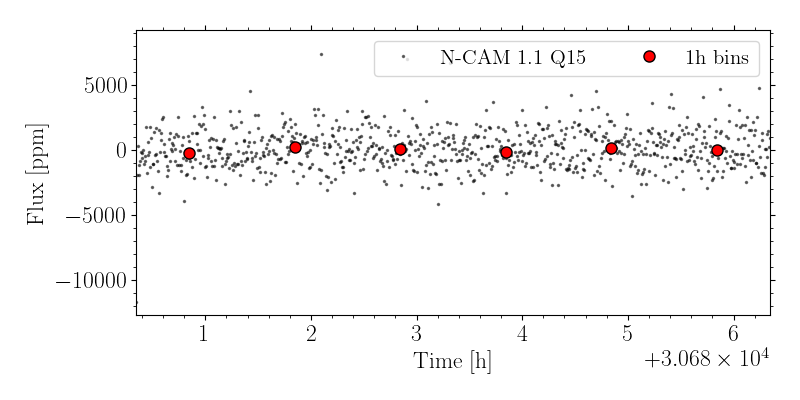

In [201]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));

In [136]:
ut.getJitterNoiseLimitNSR(0.054, tdur=25, camType='normal')

108.0

In [164]:
ut.getPhotonNoiseLimitNSR(11, passband='V', camType='normal', ncam=24, ntra=1, tdur=3600)

45.56179683564335

### NSR for all cameras

In [165]:
ofile_ncam = f'{path}/nsr_per_ncam_Q15.ftr'

# Compute NSR per camera
# lcs = LightCurve(f'{path}/nsr', 'multi')
# lcs.get_nsr_per_camera(ofile_ncam, suffix='hdf5', quarter=15)

# Load results
df = pd.read_feather(ofile_ncam)
df['Teff'] = np.ones_like(df.mag) * 6000
df['mag'] = ut.passbandConversionV2P(df.mag, df.Teff, inverse=True, method='fialho')
df.head()

,index,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR,Teff
0,0,1,2391499000005,80.607523,-31.452083,10.040025,1,2,15,2,466.800867,1766.321185,11.777123,-50.686219,-9.702416,0,0.0,134.511047,6000.0
1,0,1,2391499000005,80.607523,-31.452083,10.040025,1,3,15,2,461.171223,1769.116427,11.761951,-50.635904,-9.601082,0,0.0,138.030075,6000.0
2,0,1,2391499000005,80.607523,-31.452083,10.040025,1,4,15,2,460.502722,1770.895338,11.754474,-50.603884,-9.589049,0,0.0,138.578781,6000.0
3,0,1,2391499000005,80.607523,-31.452083,10.040025,1,5,15,2,458.002268,1775.245094,11.735547,-50.525588,-9.544041,0,0.0,133.061401,6000.0
4,0,1,2391499000005,80.607523,-31.452083,10.040025,1,6,15,2,460.472436,1770.545081,11.755826,-50.610189,-9.588504,0,0.0,135.107590,6000.0


<IPython.core.display.Javascript object>


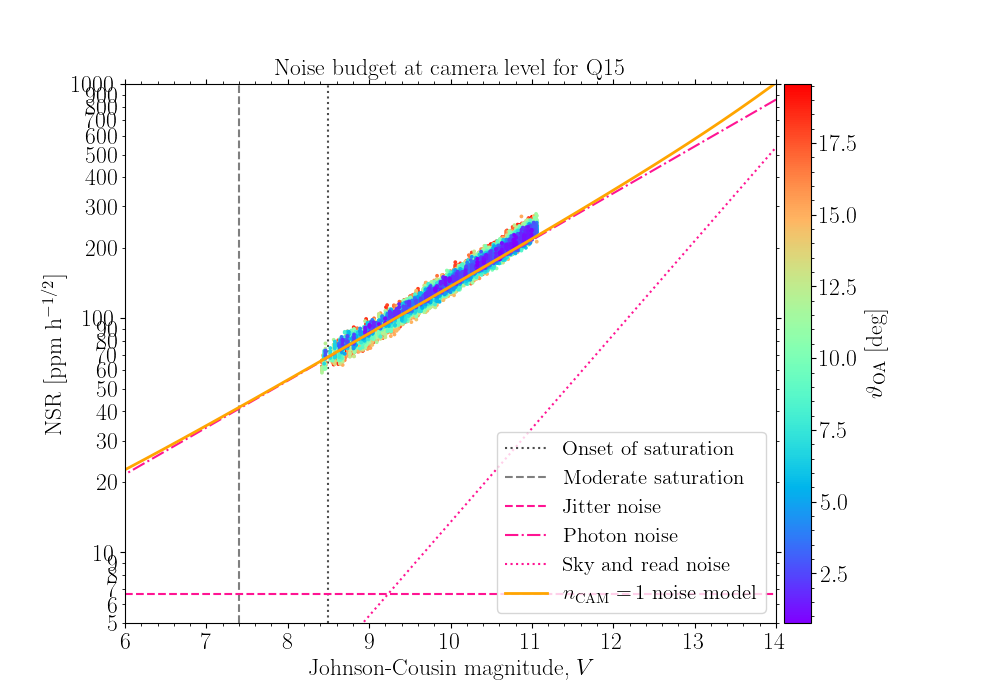

In [169]:
# Order after contaminants
col = 'rOA'
df = df.sort_values(by=[col], ascending=False)
# df = df[df.SPR < 0.06]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='V', 
                                show_ncam_noise_limits=1, 
                                show_saturation_limits=True,
                                legend=True, 
                                figsize=(10, 7))
# Settings
ax.set_title('Noise budget at camera level for Q15')
ax.set_xlim(6, 14)
ax.set_ylim(5, 1000)
# ax.set_xlim(8.3, 11.1)
# ax.set_ylim(50, 400)
plt.legend(loc='lower right');

---
## NSR at mission level
---

### Test NSR estimate

In [219]:
lcs = LightCurve(f'{path}/nsr/000000001', mode='multi')

<IPython.core.display.Javascript object>


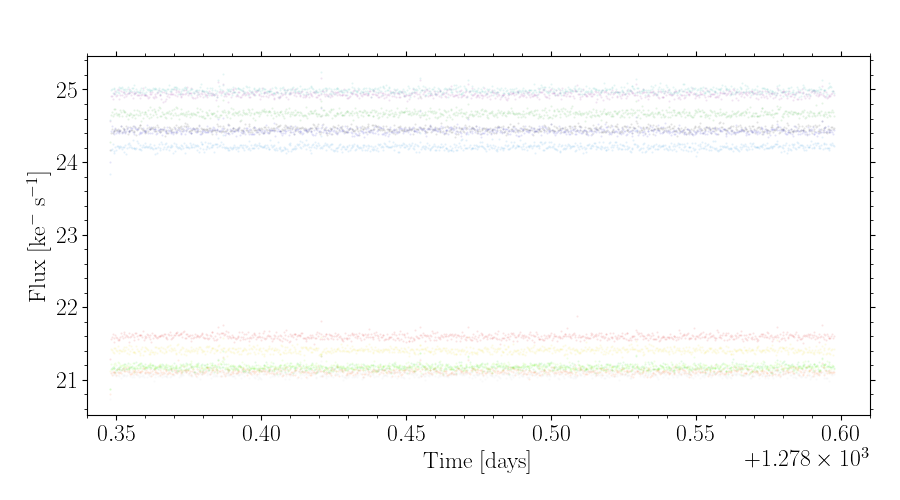

In [226]:
fig, ax = lcs.plot_multi(suffix='hdf5')
ax.set_xlim(1278.34, 1278.61);

In [231]:
lc = lcs.merge(suffix='hdf5', flux_normalise=True, flux_group_mean=True)

Processing star ID 000000001
Merging light curves


100%|██████████████████████████████████████████████████| 12/12 [00:00<00:00, 216

Sorting data after timings
Averaging data from same camera group
Done!


<IPython.core.display.Javascript object>


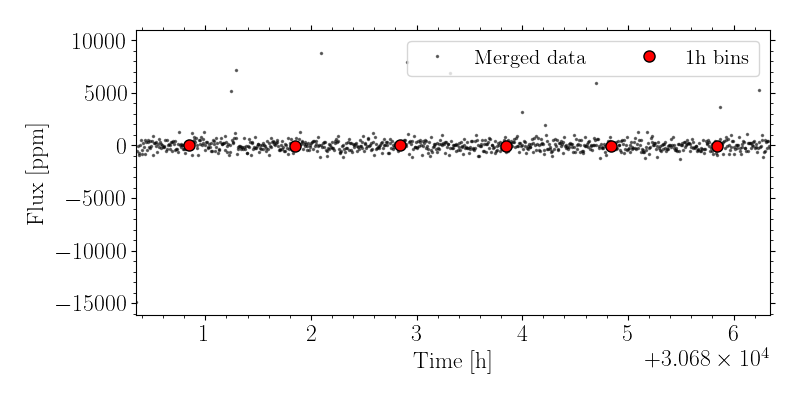

In [233]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));

In [234]:
lc.get_nsr()

72.5685048655037

In [246]:
# Filename
ofile_star = f'{path}/nsr_per_star_Q15.ftr'

# Compute NSR per star
lcs = LightCurve(f'{path}/nsr', 'multi')
lcs.get_nsr_per_star(ofile_star, suffix='hdf5', quarter=15);

# Load results
df = pd.read_feather(ofile_star)

100%|██████████████████████████████████████████████████| 1000/1000 [02:21<00:00,


In [244]:
df = pd.read_feather(ofile_ncam)
ids = df.ID.unique()
NSR = np.zeros(len(ids))
for i in ids:
    dx = df[df.ID == i]
    NSR[i-1] = dx.NSR.mean() / np.sqrt(dx.shape[0])

In [ ]:
df = pd.read_feather(ofile_star)
df['NSR'] = NSR
df['Teff'] = np.ones_like(NSR) * 6000
df['mag'] = ut.passbandConversionV2P(df.mag, df.Teff, inverse=True, method='fialho')

<IPython.core.display.Javascript object>


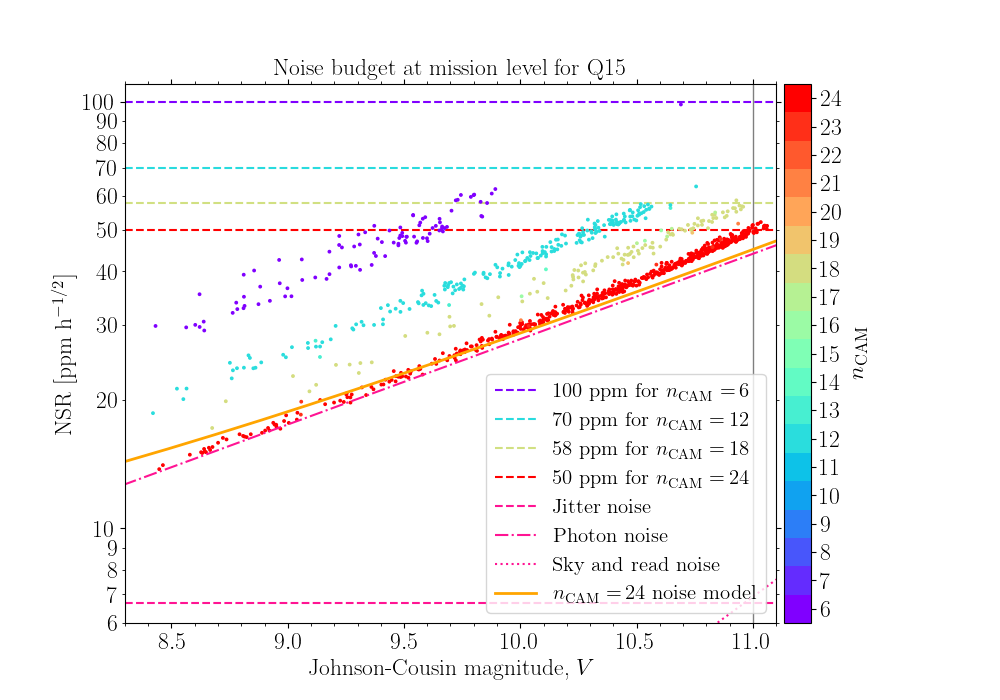

In [245]:
# Order after contaminants
col = 'ncam'
df = df.sort_values(by=[col], ascending=False)

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='V', 
                                show_targets=True,
                                residuals="multi",
                                show_ncam_noise_limits=24, 
                                figsize=(10, 7))
ax.set_title('Noise budget at mission level for Q15')
ax.set_xlim(8.3, 11.1)
ax.set_ylim(6, 110)
plt.legend();